# `find_peaks`
Finds local peaks in the distance transform.  This is need for watershed segmentations.

In [5]:
import numpy as np
import porespy as ps
import scipy.ndimage as spim
import matplotlib.pyplot as plt
from edt import edt
from IPython.display import Markdown

np.random.seed(11)
ps.visualization.set_mpl_style()
Markdown(ps.tools.show_docstring(ps.filters.find_peaks))

<details><summary><b>Click to see docs</b></summary><blockquote>
<p>Finds local maxima in the distance transform</p>
<h1 id="parameters">Parameters</h1>
<dl>
<dt>dt : ndarray</dt>
<dd>
<p>The distance transform of the pore space. This may be calculated and
filtered using any means desired.</p>
</dd>
<dt>r_max : scalar</dt>
<dd>
<p>The radius of the spherical element used in the maximum filter. This
controls the localness of any maxima. The default is 4 voxels.</p>
</dd>
<dt>strel : ndarray</dt>
<dd>
<p>Instead of supplying <code>r_max</code>, this argument allows a
custom structuring element allowing control over both size and
shape.</p>
</dd>
<dt>sigma : float or list of floats</dt>
<dd>
<p>If given, then a gaussian filter is applied to the distance transform
using this value for the kernel (i.e.
<code>scipy.ndimage.gaussian_filter(dt, sigma)</code>)</p>
</dd>
<dt>parallel_kw : dict</dt>
<dd>
<p>Dictionary containing the settings for parallelization by chunking.
The optional settings include <span class="title-ref">divs</span>
(scalar or list of scalars, default = [2, 2, 2]), <span
class="title-ref">overlap</span> (scalar or list of scalars, optional),
and <span class="title-ref">cores</span> (scalar, default is all
available cores).</p>
<p><span class="title-ref">divs</span> is the number of times to divide
the image for parallel processing. If <span class="title-ref">1</span>
then parallel processing does not occur. <span
class="title-ref">2</span> is equivalent to <span class="title-ref">[2,
2, 2]</span> for a 3D image. If a list is provided, each respective axis
will be divided by its corresponding number in the list. For example,
[2, 3, 4] will divide z, y, and x axis to 2, 3, and 4 respectively.</p>
<p><span class="title-ref">overlap</span> is the amount of overlap to
include when dividing up the image. This value is controlled by the size
(i.e. radius) of the structuring element and cannot be controlled in
this function using parallel_kw!</p>
<p><span class="title-ref">cores</span> is the number of cores that will
be used to parallel process all domains. If <code>None</code> then all
cores will be used but user can specify any integer values to control
the memory usage. Setting value to 1 will effectively process the chunks
in serial to minimize memory usage.</p>
</dd>
</dl>
<h1 id="returns">Returns</h1>
<dl>
<dt>image : ndarray</dt>
<dd>
<p>An array of booleans with <code>True</code> values at the location of
any local maxima.</p>
</dd>
</dl>
<h1 id="notes">Notes</h1>
<p>It is also possible ot the <code>peak_local_max</code> function from
the <code>skimage.feature</code> module as follows:</p>
<p><code>peaks = peak_local_max(image=dt, min_distance=r, exclude_border=0, indices=False)</code></p>
<p>The <em>skimage</em> function automatically uses a square structuring
element which is significantly faster than using a circular or spherical
element.</p>
<h1 id="examples">Examples</h1>
<p><a
href="https://porespy.org/examples/filters/reference/find_peaks.html">Click
here</a> to view online example.</p>
</blockquote>
</details>

## `dt`
The distance transform must be provided

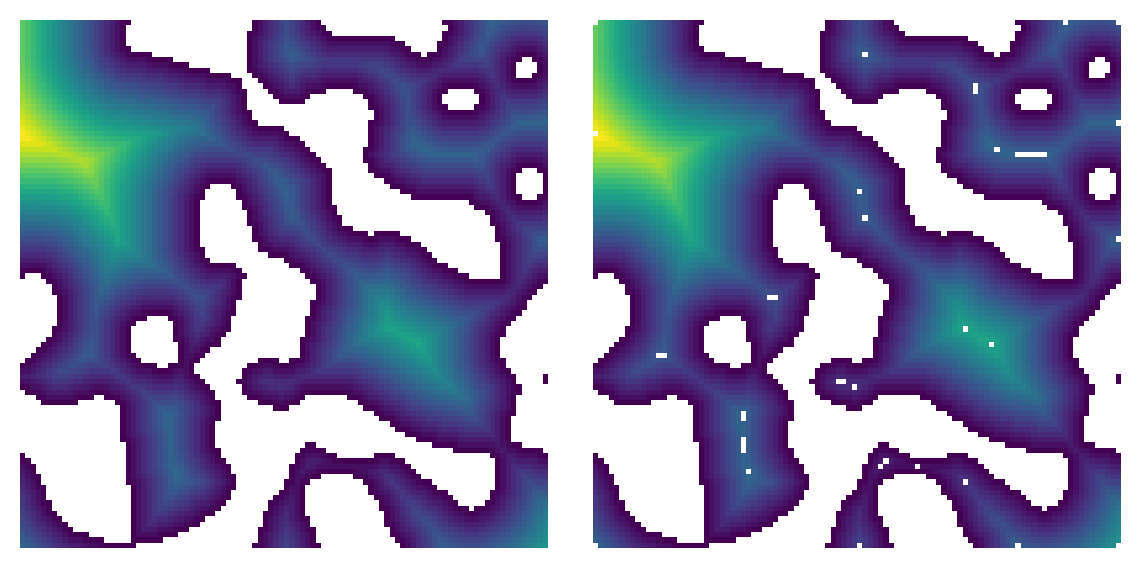

In [ ]:
im = ps.generators.blobs(shape=[100, 100], blobiness=0.5, porosity=0.7, seed=11)
dt = edt(im)

fig, ax = plt.subplots(1, 2, figsize=[6, 3])

pk = ps.filters.find_peaks(dt=dt)
ax[0].imshow(dt/im)
ax[0].axis(False)

ax[1].imshow(dt/im/~pk)
ax[1].axis(False);

## `r_max`
The radius that should be searched for local maxima.

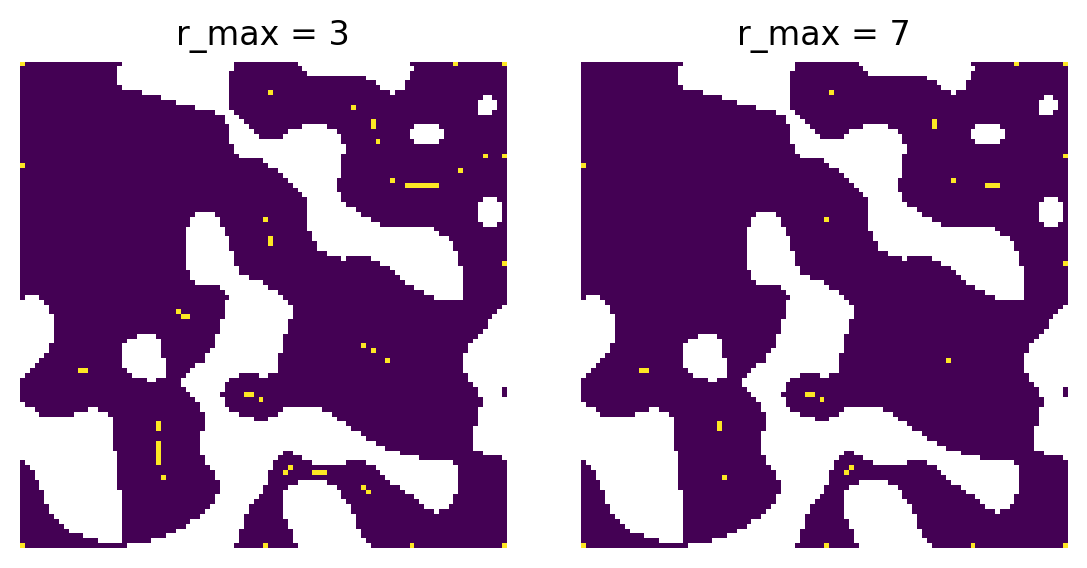

In [7]:
fig, ax = plt.subplots(1, 2, figsize=[6, 3])

r_max = 3
pk = ps.filters.find_peaks(dt=dt, r_max=r_max)
ax[0].imshow(pk/im)
ax[0].axis(False)
ax[0].set_title(f'r_max = {r_max}')

r_max = 7
pk = ps.filters.find_peaks(dt=dt, r_max=r_max)
ax[1].imshow(pk/im)
ax[1].axis(False)
ax[1].set_title(f'r_max = {r_max}');

## `strel`
The structuring element to use, in the form of a function handle. The value of `r_max` is passed to this function, so note that the meaning for `r` differs depending on the strel used. The default is a disk/ball. 

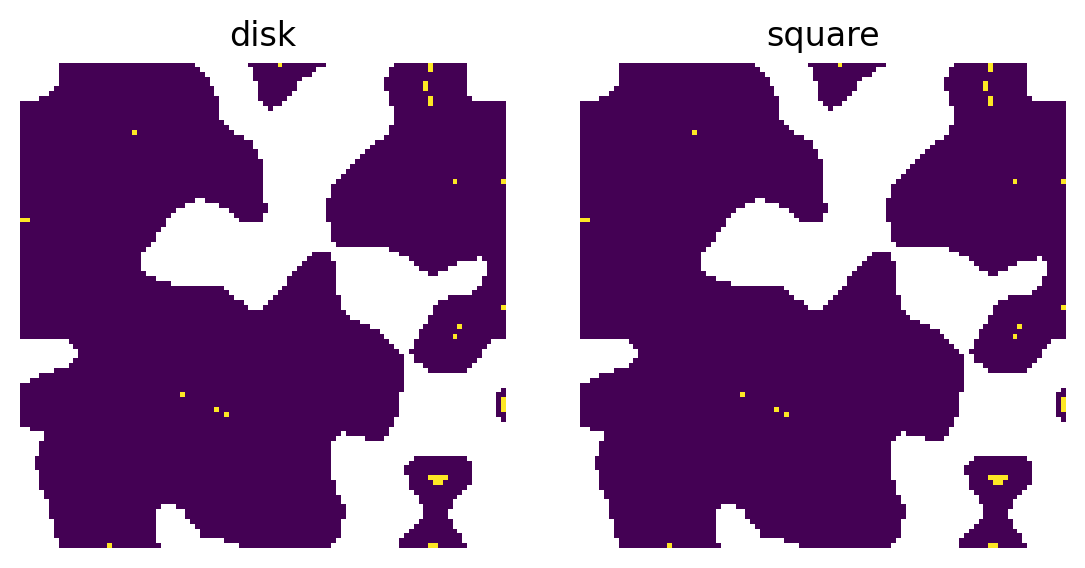

In [8]:
im = ps.generators.blobs(shape=[100, 100], blobiness=0.5, porosity=0.7)
dt = edt(im)

from skimage.morphology import disk, square

fig, ax = plt.subplots(1, 2, figsize=[6, 3])

pk = ps.filters.find_peaks(dt=dt, strel=disk(3))
ax[0].imshow(pk/im)
ax[0].axis(False)
ax[0].set_title('disk')

pk = ps.filters.find_peaks(dt=dt, strel=square(5))
ax[1].imshow(pk/im)
ax[1].axis(False)
ax[1].set_title('square');